# grantMinded

In [5]:
import os
import re
import csv
import json
import time
import random
import hashlib
import datetime as _dt
from urllib.parse import urlparse, urlunparse, urljoin

import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import joblib

In [1]:
# grantminded_corpus.py
# corpus builder for grantminded: saves html/txt and enriches scored_results.csv


# -----------------------
# config
# -----------------------
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/114.0.0.0 Safari/537.36"
    )
}

LOG_PATH = r"C:\Users\miked\Desktop2\IConnectFoundation\grantMinded\logs"
os.makedirs(LOG_PATH, exist_ok=True)

CORPUS_HTML_DIR = os.path.join(LOG_PATH, "corpus", "html")
CORPUS_TEXT_DIR = os.path.join(LOG_PATH, "corpus", "text")
os.makedirs(CORPUS_HTML_DIR, exist_ok=True)
os.makedirs(CORPUS_TEXT_DIR, exist_ok=True)

CSV_PATH = os.path.join(LOG_PATH, "scored_results.csv")

# path to saved logistic regression grant detector bundle
GRANT_MODEL_BUNDLE_PATH = r"C:\Users\miked\Desktop2\IConnectFoundation\grantMinded\grant_logreg_bundle.pkl"

# corpus cap
MAX_CORPUS_ROWS = 1000          # total rows to keep in scored_results.csv
PREFER_LABELED = True          # keep labeled rows first when capping
PRUNE_ORPHAN_FILES = False     # leave False unless you want file pruning

# ============================================================
# Domain-expert keyword weights (mission relevance)
# ============================================================
keyword_weights = {
    "aging": 3,
    "dementia": 3,
    "isolation": 4,
    "alzheimer's": 3,
    "telehealth": 2,
    "501(c)(3)": 2,
    "grant": 3,
    "funding": 3
}

# ============================================================
# Example web search queries (optional)
# ============================================================
search_keywords = [
    "aging nonprofit funding",
    "alzheimer's foundation grant",
    "dementia telehealth grant",
    "community isolation grant 501(c)(3)",
    "social isolation grant"
]

# ============================================================
# Reference text (for cosine similarity baseline)
# ============================================================
_reference_text = (
    "health care programs and partnerships that improve outcomes and quality of life for older adults, "
    "people with disabilities, and caregivers. initiatives to align health and social care, community grants, 501 c 3. "
    "leveraging technology as a tool for connection, promoting meaningful engagement"
)

# ============================================================
# Crawl config: path-level deny list
# ============================================================
# deny_list = [
#     "/blog/", "/press/", "/press-release/", "/news/",
#     "/stories/", "stories", "/story/", "story",
#     "/about/", "/team/", "/board/", "/contact", "/contact-us",
#     "/privacy", "/terms", "/careers", "/jobs", "/event", "/events",
#     "/media", "/newsletter", "/subscribe", "/search",
#     "/login", "/sign-in", "/signin", "/sign_in",
#     "/cart", "/donate", "/grantee-stories/",
#     "/faq/", "faq", "frequently asked questions", "frequently-asked-questions"
# ]

deny_list = [
    "blog", "press", "press-release", "news",
    "stories", "story",
    "about", "team", "board", "contact", "contact-us",
    "privacy", "terms", "careers", "jobs", "event", "events",
    "media", "newsletter", "subscribe", "search",
    "login", "sign-in", "signin", "sign_in",
    "cart", "donate", "grantee-stories",
    "faq", "frequently asked questions", "frequently-asked-questions"
]

# ============================================================
# Keywords that suggest a page *might* be a grant listing
# ============================================================
allow_hint_keywords = [
    "grant","grants","fund","funds","funding",
    "opportunity","opportunities","rfp","rfa","rfi",
    "request-for-proposals","request for proposals",
    "apply","application","guidelines","program","loi","initiative",
    "grant-opportunities","grant-opportunit"
]

# ============================================================
# Binary / non-HTML extensions to ignore
# ============================================================
BINARY_EXTS = (
    ".pdf",".doc",".docx",".xls",".xlsx",".ppt",".pptx",
    ".zip",".rar",".7z",".png",".jpg",".jpeg",".gif",".svg",
    ".mp3",".mp4",".mov",".avi",".wav"
)



deny_domains = [
    # Paid grant databases / subscription services
    "grantwatch.com",
    "www.grantwatch.com",
    "grantportal.com",
    "www.grantportal.com",
    "thegrantportal.com",
    "www.thegrantportal.com",
    "grantstation.com",
    "www.grantstation.com",
    "instrumentl.com",
    "www.instrumentl.com",
    "grantgopher.com",
    "www.grantgopher.com",
    "grantselect.com",
    "www.grantselect.com",
    "grantforward.com",
    "www.grantforward.com",
    "devex.com",
    "www.devex.com",
    "catholicfundingguide.com",
    "www.catholicfundingguide.com",

    # Other paid or semi-paid grant warehouses / dubious aggregators
    "fundsforngos.org",
    "www.fundsforngos.org",
    "grantadvisor.org",          # requires log-in & community reviewed
    "grantdomain.com",
    "www.grantdomain.com",

    # Senior/grants scam-like aggregators
    "grantsforseniors.org",
    "www.grantsforseniors.org",
    "benefits.gov",              # Not a grant portal, but often a dead end for your use case
    "www.benefits.gov",

    # Sites known to block scraping or require login/payment
    "grantfinder.com",
    "www.grantfinder.com",
    "foundationsearch.com",
    "www.foundationsearch.com",
    "candid.org",                # Includes Foundation Directory Online (paid)
    "www.candid.org",
    "fconlinefoundationcenter.org",
    "www.fconlinefoundationcenter.org",
]

# ============================================================
# Global scrape counter
# ============================================================
SCRAPE_COUNTER = 0


In [ ]:
%pip install -U ddgs duckduckgo-search googlesearch-python

In [3]:
from urllib.parse import urlparse

# -----------------------
# helpers: ids, time, text clean
# -----------------------
def normalize_url(u):
    p = urlparse(u)
    p = p._replace(fragment="")
    return urlunparse((p.scheme.lower(), p.netloc.lower(), p.path, p.params, p.query, ""))

def doc_id_from_url(u):
    return hashlib.sha1(normalize_url(u).encode("utf-8")).hexdigest()[:16]

def now_iso_utc():
    t = _dt.datetime.now(_dt.timezone.utc).replace(microsecond=0)
    return t.isoformat().replace("+00:00", "Z")

def html_to_clean_text(html):
    soup = BeautifulSoup(html, "html.parser")
    for tag in soup(["script", "style", "noscript"]):
        tag.decompose()
    text = soup.get_text(separator=" ", strip=True)
    return re.sub(r"\s+", " ", text).strip()

def content_sha1(text):
    return hashlib.sha1((text or "").encode("utf-8")).hexdigest()

def corpus_full():
    """Return True if corpus/text already has max or more saved pages."""
    try:
        files = [
            f for f in os.listdir(CORPUS_TEXT_DIR)
            if f.lower().endswith(".txt")
        ]
        return len(files) >= MAX_CORPUS_ROWS  
    except Exception:
        return False

# -----------------------
# stage 1: keyword score
# -----------------------
def keyword_score(text, keywords):
    score = 0
    matched = []
    t = (text or "").lower()
    for word, weight in keywords.items():
        pat = rf"\b{re.escape(word.lower())}\b"
        if re.search(pat, t):
            score += weight
            matched.append(word)
    return score, matched

# -----------------------
# stage 2: cosine score (tf-idf)
# -----------------------
def _simple_tokenizer(s):
    s = re.sub(r"[^a-z0-9\s]", " ", (s or "").lower())
    toks = s.split()
    return [t for t in toks if len(t) > 2]

def cosine_score(grant_text, ref_text=_reference_text):
    docs = [ref_text, grant_text or ""]
    vec = TfidfVectorizer(stop_words="english", tokenizer=_simple_tokenizer, token_pattern=None)
    m = vec.fit_transform(docs)
    sim = cosine_similarity(m[0:1], m[1:2])[0][0]
    return float(sim)

# -----------------------
# load logistic regression grant detector
# -----------------------
GRANT_VECTORIZER = None
GRANT_SCALER = None
GRANT_MODEL = None
GRANT_THRESHOLD = 0.1  # explicit threshold

try:
    if os.path.exists(GRANT_MODEL_BUNDLE_PATH):
        _bundle = joblib.load(GRANT_MODEL_BUNDLE_PATH)
        GRANT_VECTORIZER = _bundle.get("vectorizer", None)
        GRANT_SCALER = _bundle.get("scaler", None)
        GRANT_MODEL = _bundle.get("model", None)
        if "threshold" in _bundle:
            # you said to use 0.1; we respect that explicitly
            GRANT_THRESHOLD = 0.1
        print(f"Loaded grant LR model bundle from {GRANT_MODEL_BUNDLE_PATH}")
    else:
        print(f"WARNING: grant model bundle not found at {GRANT_MODEL_BUNDLE_PATH}")
except Exception as e:
    print(f"WARNING: could not load grant model bundle: {e}")

def is_grant_by_lr(text, threshold=GRANT_THRESHOLD):
    """
    Use pretrained logistic regression (TF-IDF + scaler) to decide if text describes a grant.
    Returns (is_grant_bool, prob).
    If model missing, falls back to (True, 1.0) so we don't silently drop pages.
    """
    if not text or len(text.strip()) < 50:
        return False, 0.0

    if GRANT_MODEL is None or GRANT_VECTORIZER is None:
        # fail-safe: keep the page but warn
        # print("WARNING: GRANT_MODEL not loaded; treating all pages as grants.")
        return True, 1.0

    X = GRANT_VECTORIZER.transform([text])
    if GRANT_SCALER is not None:
        X = GRANT_SCALER.transform(X)
    prob = float(GRANT_MODEL.predict_proba(X)[0][1])
    return prob >= threshold, prob

# -----------------------
# http fetch
# -----------------------
def scrape_website(url, timeout=15):
    # skip denied urls before hitting the network
    if is_denied_url(url):
        print(f"skipping denied url {url}")
        return url, "", None

    try:
        r = requests.get(url, headers=HEADERS, timeout=timeout, allow_redirects=True)
        r.raise_for_status()
        soup = BeautifulSoup(r.text, "html.parser")
        text = soup.get_text(separator=" ", strip=True)
        return url, text, soup
    except Exception as e:
        print(f"error scraping {url}: {e}")
        return url, "", None

def _seed_looks_promising(url: str, title: str = "", text: str = "") -> bool:
    ul = (url or "").lower()
    tl = (title or text or "").lower()
    return any(tok in ul for tok in allow_hint_keywords) or any(tok in tl for tok in allow_hint_keywords)

# -----------------------
# web search (ddgs primary -> duckduckgo_search -> googlesearch)
# -----------------------
def _norm(u):
    try:
        p = urlparse(u)
        return f"{p.scheme.lower()}://{p.netloc.lower()}{p.path}".rstrip("/")
    except Exception:
        return u

def _limit_per_domain(urls, max_per_domain=5):
    out, seen = [], {}
    for u in urls:
        host = urlparse(u).netloc.lower()
        seen[host] = seen.get(host, 0) + 1
        if seen[host] <= max_per_domain:
            out.append(u)
    return out

def search_web(query, max_results=30):
    urls_raw = []

    q = query.replace("501(c)(3)", '("501(c)(3)" OR 501c3)')

    try:
        from ddgs import DDGS
        with DDGS() as ddgs:
            res = list(ddgs.text(q, max_results=max_results*2))
            urls_raw.extend([(r.get("href"), r.get("title", "")) for r in res if r.get("href")])
        print(f"ddgs returned {len(urls_raw)} raw results for: {query}")
    except Exception as e:
        print(f"ddgs error for '{query}': {e}")
        try:
            from duckduckgo_search import DDGS as OldDDGS
            with OldDDGS() as ddgs:
                res = list(ddgs.text(q, max_results=max_results*2))
                urls_raw.extend([(r.get("href"), r.get("title", "")) for r in res if r.get("href")])
            print(f"duckduckgo_search returned {len(urls_raw)} raw results for: {query}")
        except Exception as e2:
            print(f"duckduckgo_search error for '{query}': {e2}")

    if len(urls_raw) < max_results:
        try:
            from googlesearch import search as gsearch
            g = [(u, "") for u in gsearch(q, num_results=max_results) if u]
            urls_raw.extend(g)
            print(f"googlesearch returned {len(g)} raw results for: {query}")
        except Exception as e:
            print(f"googlesearch blocked/unavailable for '{query}': {e}")

    filtered = []
    for href, title in urls_raw:
        if not href or not href.startswith("http"):
            continue
        # skip denied urls (grantwatch, grantportal, etc.)
        if is_denied_url(href):
            continue
        if _seed_looks_promising(href, title):
            filtered.append(_norm(href))

    filtered = list(dict.fromkeys(filtered))
    filtered = _limit_per_domain(filtered, max_per_domain=5)
    random.shuffle(filtered)
    filtered = filtered[:max_results]

    print(f"using {len(filtered)} urls after filters for: {query}")
    return filtered

def google_search(query, num_results=40):
    return search_web(query, max_results=num_results)

# -----------------------
# url helpers
# -----------------------
def _strip_www(host: str) -> str:
    return host[4:] if host.lower().startswith("www.") else host.lower()

def same_domain(u, base):
    try:
        hu = _strip_www(urlparse(u).netloc)
        hb = _strip_www(urlparse(base).netloc)
        return hu == hb or hu.endswith("." + hb) or hb.endswith("." + hu)
    except Exception:
        return False

def is_denied_url(u):
    """
    Unified url filter:
    - blocks binary files (BINARY_EXTS)
    - blocks deny_domains (grantwatch, thegrantportal, etc.)
    - blocks any URL whose PATH contains any phrase from deny_list
    """
    try:
        p = urlparse(u)
    except Exception:
        return True  # if we can't parse it, drop it

    host = (p.netloc or "").lower()
    path = (p.path or "").lower()

    # block binary file types
    for ext in BINARY_EXTS:
        if path.endswith(ext):
            return True

    # domain-level blocks
    for dom in deny_domains:
        if host.endswith(dom):
            return True

    # path-level substring blocks (NEW behavior)
    for d in deny_list:
        d_clean = d.strip().lower()
        if not d_clean:
            continue
        if d_clean in path:
            return True

    return False

def looks_relevant_link(href, text_lower):
    href_l = (href or "").lower()
    if any(k in href_l for k in allow_hint_keywords):
        return True
    if any(k in (text_lower or "") for k in allow_hint_keywords):
        return True
    return False

# -----------------------
# link extraction
# -----------------------
def extract_links(current_url, soup, base_url, generic_cap=20):
    links_priority, links_generic = [], []
    if soup is None:
        return []

    for a in soup.find_all("a", href=True):
        href = a.get("href") or ""
        href_l = href.lower()

        if href_l.startswith("#") or href_l.startswith("mailto:") \
           or href_l.startswith("tel:") or href_l.startswith("javascript:"):
            continue

        link = urljoin(current_url, href)
        if not link.startswith(("http://","https://")):
            continue
        if not same_domain(link, base_url):
            continue
        if is_denied_url(link):  # <-- unified domain + path + binary check
            continue

        txt = (a.get_text(strip=True) or "").lower()

        is_pagination = bool(
            re.search(r"(next|older|previous|more|>>|«|»|‹|›|load more|page\s*\d+)", txt)
            or re.search(r"(?:[?&](?:page|p|start|offset)=\d+)", link, re.I)
        )

        if looks_relevant_link(href, txt) or is_pagination:
            links_priority.append(link)
        else:
            links_generic.append(link)

    seen, out = set(), []
    for u in links_priority + links_generic[:generic_cap]:
        if u not in seen:
            seen.add(u)
            out.append(u)
    return out

# -----------------------
# save detail page + build row
# -----------------------
def save_detail_page_and_row(url, soup, k_score, matched_list, c_score, scrape_num):
    html_raw = str(soup)
    clean_text = html_to_clean_text(html_raw)

    did = doc_id_from_url(url)
    html_path = os.path.join(CORPUS_HTML_DIR, f"{did}.html")
    text_path = os.path.join(CORPUS_TEXT_DIR, f"{did}.txt")

    with open(html_path, "w", encoding="utf-8", errors="ignore") as f:
        f.write(html_raw)
    with open(text_path, "w", encoding="utf-8", errors="ignore") as f:
        f.write(clean_text)

    # per-keyword binary flags
    matched_set = set(matched_list)
    aging = 1 if "aging" in matched_set else 0
    dementia = 1 if "dementia" in matched_set else 0
    alzhiemers = 1 if "alzheimer's" in matched_set else 0
    isolation = 1 if "isolation" in matched_set else 0
    telehealth = 1 if "telehealth" in matched_set else 0
    np_501c3 = 1 if "501(c)(3)" in matched_set else 0
    grant_kw = 1 if "grant" in matched_set else 0
    funding_kw = 1 if "funding" in matched_set else 0

    row = {
        "url": normalize_url(url),
        "scrape_num": scrape_num,
        "content_snippet": clean_text[:2000],
        "score": float(k_score + (c_score or 0.0)),
        "matched_keywords": ", ".join(matched_list),
        "num_keywords": len(matched_list),
        "aging": aging,
        "dementia": dementia,
        "alzhiemers": alzhiemers,
        "isolation": isolation,
        "telehealth": telehealth,
        "np_501c3": np_501c3,
        "grant": grant_kw,
        "funding": funding_kw,
        "relevence_label": "",        # to be hand-labeled later
        "grant_yesno": "grant",       # only saving pages classified as grants
        "label_note": "",
        "keyword_score": k_score,
        "cosine_similarity": round(float(c_score or 0.0), 6),
        "granting_organization": "",
        "date_of_loi_due": "",
        "date_of_submission": "",
        "doc_id": did,
        "source_domain": urlparse(url).netloc,
        "html_path": os.path.abspath(html_path),
        "content_sha1": content_sha1(clean_text),
        "is_detail_page": 1,
        "text_path": os.path.abspath(text_path),

        # extra meta (not in your required list but useful for sorting)
        "date_seen_utc": now_iso_utc()
    }
    return row

# -----------------------
# csv helpers
# -----------------------
def read_csv_safe(path):
    for enc in ("utf-8", "utf-8-sig", "latin1", "cp1252"):
        try:
            return pd.read_csv(path, encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, encoding="utf-8", encoding_errors="replace")

def existing_keys(df, key_cols):
    if not set(key_cols).issubset(df.columns):
        return set()
    if len(key_cols) == 1:
        return set(df[key_cols[0]].astype(str))
    return set(map(tuple, df[key_cols].astype(str).itertuples(index=False, name=None)))

def enforce_corpus_cap(df_all: pd.DataFrame,
                       max_rows: int,
                       prefer_labeled: bool = True) -> pd.DataFrame:
    if max_rows is None or max_rows <= 0 or len(df_all) <= max_rows:
        return df_all

    rel = df_all["relevance"].astype(str).str.strip().fillna("") if "relevance" in df_all.columns else pd.Series([""]*len(df_all))
    vlabel = df_all["valid_label"].astype(str).str.strip().fillna("") if "valid_label" in df_all.columns else pd.Series([""]*len(df_all))
    is_labeled = (rel != "") | (vlabel.str.lower() != "unlabeled")

    if prefer_labeled and is_labeled.any():
        df_lab = df_all[is_labeled].copy()
        df_unl = df_all[~is_labeled].copy()

        if len(df_lab) >= max_rows:
            return df_lab.tail(max_rows).copy()

        remaining = max_rows - len(df_lab)
        return pd.concat([df_lab, df_unl.tail(remaining)], ignore_index=True)
    else:
        return df_all.tail(max_rows).copy()

def prune_orphan_files(df_all: pd.DataFrame):
    if "doc_id" not in df_all.columns:
        print("prune_orphan_files: skipped (no 'doc_id' column).")
        return

    keep = set(df_all["doc_id"].astype(str))
    removed = 0

    def _rm(path):
        nonlocal removed
        try:
            if os.path.exists(path):
                os.remove(path)
                removed += 1
        except Exception as e:
            print(f"  could not remove {path}: {e}")

    for fname in os.listdir(CORPUS_HTML_DIR):
        if not fname.lower().endswith(".html"):
            continue
        did = os.path.splitext(fname)[0]
        if did not in keep:
            _rm(os.path.join(CORPUS_HTML_DIR, fname))

    for fname in os.listdir(CORPUS_TEXT_DIR):
        if not fname.lower().endswith(".txt"):
            continue
        did = os.path.splitext(fname)[0]
        if did not in keep:
            _rm(os.path.join(CORPUS_TEXT_DIR, fname))

    if removed:
        print(f"prune_orphan_files: removed {removed} old files.")


# -----------------------
# crawler
# -----------------------
def crawl_site(start_url, max_pages=300, max_depth=3):
    visited = set()
    results = []

    def crawl(url, depth_left):
        nonlocal results
        global SCRAPE_COUNTER

        # stop if depth exhausted or too many pages visited
        if depth_left < 0 or len(visited) >= max_pages:
            return

        # stop if corpus is already full
        if corpus_full():
            print("\n******* STOPPING: corpus reached max saved grants *******\n")
            return

        # skip denied urls (domain/path/binary)
        if is_denied_url(url):
            print(f"skipping denied url {url}")
            return

        if url in visited:
            return
        visited.add(url)

        print(f"visiting {url} (depth {depth_left})")
        url, raw_text, soup = scrape_website(url)
        if not soup or not raw_text:
            return

        # clean text for lr + keyword/cosine
        html_raw = str(soup)
        clean_text = html_to_clean_text(html_raw)

        # stage 1: grant/not-grant via lr (broad gate)
        is_grant, prob = is_grant_by_lr(clean_text, threshold=GRANT_THRESHOLD)

        if is_grant:
            # stage 2: mission scoring (keyword + cosine) for candidate grants
            try:
                k_score, matched = keyword_score(clean_text, keyword_weights)
                c_score = cosine_score(clean_text)
            except Exception as e:
                print(f"  error computing keyword/cosine for {url}: {e}")
                k_score, matched, c_score = 0, [], 0.0

            # mission filter: keep only if keyword_score >= 7 OR cosine >= 0.07
            mission_ok = (k_score >= 7) or (c_score >= 0.07)

            if mission_ok:
                SCRAPE_COUNTER += 1
                print(
                    f"  SAVED grant (scrape_num={SCRAPE_COUNTER}): "
                    f"prob={round(prob,3)}, "
                    f"keyword_score={k_score}, cosine={round(c_score,3)}, "
                    f"matched={matched}"
                )
                row = save_detail_page_and_row(
                    url, soup, k_score, matched, c_score, scrape_num=SCRAPE_COUNTER
                )
                results.append(row)

                # HARD STOP — stop crawling when max text files exist
                if corpus_full():
                    print("\n******* STOPPING: corpus reached max saved grants *******\n")
                    return
            else:
                print(
                    f"  LR says GRANT but mission filter failed: "
                    f"keyword_score={k_score}, cosine={round(c_score,3)}"
                )
        else:
            print(f"  LR says NOT GRANT: prob={round(prob,3)}")

        # stop before exploring more links if corpus is full
        if corpus_full():
            print("\n******* STOPPING BEFORE LINK EXPANSION: corpus full *******\n")
            return

        # crawl links regardless of whether we saved this page
        child_links = extract_links(url, soup, start_url)
        for nxt in child_links[:50]:
            crawl(nxt, depth_left - 1)

    crawl(start_url, max_depth)
    return results



Loaded grant LR model bundle from C:\Users\miked\Desktop2\IConnectFoundation\grantMinded\grant_logreg_bundle.pkl


In [5]:
# -----------------------
# pipeline
# -----------------------
def run_pipeline(depth=3):
    results = []

    static_urls = [
        "https://www.rwjf.org/en/grants/active-funding-opportunities.html",
        "https://www.eda.gov/funding/funding-opportunities",
        "https://www.walmart.org/how-we-give/open-applications",
        "https://www.gatesfoundation.org/about/how-we-work/grant-opportunities"
    ]

    # crawl static seeds
    for url in static_urls:
        print(f"\nSCRAPING LISTING: {url}")
        try:
            grant_rows = crawl_site(url, max_pages=600, max_depth=depth)
            results.extend(grant_rows)
        except Exception as e:
            print(f"error on static url {url}: {e}")

    # discovery via web search
    for query in search_keywords:
        print(f"\nSEARCHING WEB FOR: '{query}'")
        try:
            found = search_web(query, max_results=30)
        except Exception as e:
            print(f"search error for '{query}': {e}")
            found = []

        for url in found:
            print(f"  seed from search: {url}")
            try:
                grant_rows = crawl_site(url, max_pages=400, max_depth=depth)
                results.extend(grant_rows)
            except Exception as e:
                print(f"error on discovered url {url}: {e}")
            time.sleep(0.5)

    # build dataframe for new results
    df_new = pd.DataFrame(results)

    # enforce column order and fill missing columns
    desired_cols = [
        "url",
        "scrape_num",
        "content_snippet",
        "score",
        "matched_keywords",
        "num_keywords",
        "aging",
        "dementia",
        "alzhiemers",
        "isolation",
        "telehealth",
        "np_501c3",
        "grant",
        "funding",
        "relevence_label",
        "grant_yesno",
        "label_note",
        "keyword_score",
        "cosine_similarity",
        "granting_organization",
        "date_of_loi_due",
        "date_of_submission",
        "doc_id",
        "source_domain",
        "html_path",
        "content_sha1",
        "is_detail_page",
        "text_path"
    ]

    # if CSV exists, append
    if os.path.exists(CSV_PATH):
        df_old = read_csv_safe(CSV_PATH)

        # align columns both ways
        for col in desired_cols:
            if col not in df_old.columns:
                df_old[col] = ""
            if col not in df_new.columns:
                df_new[col] = ""

        # keep any extra columns (like date_seen_utc) if already present
        for col in df_old.columns:
            if col not in df_new.columns:
                df_new[col] = ""

        # choose uniqueness key
        if "doc_id" in df_old.columns and "doc_id" in df_new.columns:
            key_cols = ["doc_id"]
        elif "content_sha1" in df_old.columns and "content_sha1" in df_new.columns:
            key_cols = ["content_sha1"]
        else:
            key_cols = ["url"]

        old = existing_keys(df_old, key_cols)

        if len(key_cols) == 1:
            df_new_unique = df_new[~df_new[key_cols[0]].astype(str).isin(old)].copy()
        else:
            df_new_unique = df_new[
                ~df_new[key_cols].astype(str).apply(tuple, axis=1).isin(old)
            ].copy()

        n_added = len(df_new_unique)
        df_all = pd.concat([df_old, df_new_unique], ignore_index=True)
    else:
        # first run: everything is new
        # ensure all desired columns present
        for col in desired_cols:
            if col not in df_new.columns:
                df_new[col] = ""
        df_all = df_new
        n_added = len(df_new)

    # sort by date_seen_utc if present
    if "date_seen_utc" in df_all.columns:
        df_all = df_all.sort_values("date_seen_utc")
    df_all = df_all.reset_index(drop=True)

    # enforce overall cap
    max_rows = MAX_CORPUS_ROWS
    prefer_labeled = PREFER_LABELED
    prune_files = PRUNE_ORPHAN_FILES

    if max_rows:
        before_cap = len(df_all)
        df_all = enforce_corpus_cap(df_all, max_rows, prefer_labeled=prefer_labeled)
        after_cap = len(df_all)
        if after_cap < before_cap:
            print(
                f"Corpus capped at {max_rows} rows "
                f"(dropped {before_cap - after_cap} oldest rows"
                f"{' while preserving labeled' if prefer_labeled else ''})."
            )

        if prune_files:
            prune_orphan_files(df_all)

    # enforce final column order for save
    for col in desired_cols:
        if col not in df_all.columns:
            df_all[col] = ""
    df_all = df_all[desired_cols + [c for c in df_all.columns if c not in desired_cols]]

    df_all.to_csv(CSV_PATH, index=False, encoding="utf-8")
    print(f"\nOK: appended {n_added} new rows; total {len(df_all)} rows saved to {CSV_PATH}")


In [7]:
# -----------------------
# entry point
# -----------------------
if __name__ == "__main__":
    run_pipeline(depth=4)


SCRAPING LISTING: https://www.rwjf.org/en/grants/active-funding-opportunities.html
visiting https://www.rwjf.org/en/grants/active-funding-opportunities.html (depth 4)
  SAVED grant (scrape_num=1): prob=0.879, keyword_score=6, cosine=0.097, matched=['grant', 'funding']
visiting https://www.rwjf.org/en/grants.html (depth 3)
  SAVED grant (scrape_num=2): prob=0.71, keyword_score=6, cosine=0.13, matched=['grant', 'funding']
visiting https://www.rwjf.org/en/grants/awarded-grants.html (depth 2)
  SAVED grant (scrape_num=3): prob=0.792, keyword_score=6, cosine=0.096, matched=['grant', 'funding']
visiting https://www.rwjf.org/en/grants/grant-process.html (depth 1)
  SAVED grant (scrape_num=4): prob=0.784, keyword_score=6, cosine=0.095, matched=['grant', 'funding']
visiting https://www.rwjf.org/en/grants/grantee-resources.html (depth 0)
  LR says GRANT but mission filter failed: keyword_score=3, cosine=0.024
visiting https://www.rwjf.org/content/granteeresources.html (depth 0)
  LR says GRANT 

C:\Users\miked\anaconda3\Lib\html\parser.py:171: XMLParsedAsHTMLWarning: It looks like you're parsing an XML document using an HTML parser. If this really is an HTML document (maybe it's XHTML?), you can ignore or filter this warning. If it's XML, you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the lxml package installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.
  k = self.parse_starttag(i)


  LR says GRANT but mission filter failed: keyword_score=3, cosine=0.023
visiting https://philanthropynetwork.org/funding-area/community-improvement?f%5B0%5D=field_funding_area%3A243&f%5B1%5D=type%3Aevent (depth 0)
  LR says GRANT but mission filter failed: keyword_score=6, cosine=0.054
visiting https://philanthropynetwork.org/funding-area/community-improvement?f%5B0%5D=field_funding_area%3A243&f%5B1%5D=type%3Ablog (depth 0)
  LR says GRANT but mission filter failed: keyword_score=3, cosine=0.047
visiting https://philanthropynetwork.org/funding-area/community-improvement?f%5B0%5D=field_funding_area%3A243&f%5B1%5D=field_funding_area%3A229 (depth 0)
  LR says GRANT but mission filter failed: keyword_score=6, cosine=0.056
visiting https://philanthropynetwork.org/funding-area/community-improvement?f%5B0%5D=field_funding_area%3A243&f%5B1%5D=field_funding_area%3A26 (depth 0)
  LR says GRANT but mission filter failed: keyword_score=6, cosine=0.055
visiting https://philanthropynetwork.org/fund

## Revieing Keyword/Cosigne Significance to identify thresholds

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, f_oneway

# ===========================================
# 1. LOAD DATA
# ===========================================
df = pd.read_excel(r"C:\Users\miked\Desktop2\IConnectFoundation\grantMinded\logs\scored_results.xlsx")

# Keep only groups 0 and 1 (drop group "d")
df = df[df["relevence_label"].isin([0, 1])]

# Split groups
g0 = df[df["relevence_label"] == 0]["score"]
g1 = df[df["relevence_label"] == 1]["score"]

In [ ]:
# ===========================================
# 2. WELCH TWO-SAMPLE T-TEST
# ===========================================
t_stat, p_val = ttest_ind(g0, g1, equal_var=False)

print("Welch t-test:")
print("t =", t_stat)
print("p =", p_val)

In [ ]:
# ===========================================
# 3. COHEN'S d (Hedges' correction optional)
# ===========================================
mean0, mean1 = g0.mean(), g1.mean()
sd0, sd1 = g0.std(ddof=1), g1.std(ddof=1)
n0, n1 = len(g0), len(g1)

# Pooled SD for Cohen's d (unequal n)
sd_pooled = np.sqrt(((n0-1)*sd0**2 + (n1-1)*sd1**2) / (n0+n1-2))
cohens_d = (mean0 - mean1) / sd_pooled

print("\nCohen's d:", cohens_d)

In [ ]:
# ===========================================
# 4. 95% CONFIDENCE INTERVAL FOR MEAN DIFFERENCE
# ===========================================
# Welch standard error
se = np.sqrt(sd0**2/n0 + sd1**2/n1)

# Welch df
df_welch = (sd0**2/n0 + sd1**2/n1)**2 / (
    (sd0**2/n0)**2/(n0-1) + (sd1**2/n1)**2/(n1-1)
)

# Critical t for 95%
from scipy.stats import t
t_crit = t.ppf(1 - 0.025, df_welch)

# CI
mean_diff = mean0 - mean1
ci_low = mean_diff - t_crit*se
ci_high = mean_diff + t_crit*se

print("\n95% CI for (mean0 - mean1):")
print((ci_low, ci_high))

In [ ]:
# ===========================================
# 5. ONE-WAY ANOVA (groups 0 vs 1)
# ===========================================
f_stat, p_anova = f_oneway(g0, g1)

print("\nANOVA (0 vs 1):")
print("F =", f_stat)
print("p =", p_anova)

In [ ]:
import statsmodels.api as sm
# -----------------------------
# 2. Clean missing or infinite values
# -----------------------------
# Replace inf with NaN
df2 = df.replace([np.inf, -np.inf], np.nan)

# Drop rows where score or cosine are missing
df2 = df2.dropna(subset=["score", "cosine_similarity"])

# -----------------------------
# 3. Define variables
# -----------------------------
y = df2["relevence_label"].astype(int)
X = df2[["score", "cosine_similarity"]]

# statsmodels requires manual intercept
X = sm.add_constant(X)

# -----------------------------
# 4. Fit logistic regression
# -----------------------------
model = sm.Logit(y, X)
result = model.fit()

# -----------------------------
# 5. Results
# -----------------------------
print(result.summary())

# Odds ratios
print("\nOdds Ratios:")
print(np.exp(result.params))

# 95% CI for odds ratios
conf = result.conf_int()
conf.columns = ["2.5%", "97.5%"]
print("\n95% CI (Odds Ratios):")
print(np.exp(conf))

In [ ]:
# Split groups
g0cs = df2[df2["relevence_label"] == 0]["cosine_similarity"]
g1cs = df2[df2["relevence_label"] == 1]["cosine_similarity"]
t_stat, p_val = ttest_ind(g0cs, g1cs, equal_var=False)

print("Welch t-test:")
print("t =", t_stat)
print("p =", p_val)

Interpretation:
keyword score: significant at 0.16, coefficent = 0.2004, for each +1 of keyword score log-odds being relevent increases by 0.2 and odss ration = 1.22. each single poitn increase in keyword score inscrease the odds of relevencen by 22%. Group 0 mean = 6.689 sd = 3.4677 n = 900 | Group 1 mean = 9.0185 sd = 3.5388 n = 13. Scraping thresholds keep if 7 

cosign similary: significant p< 0.0001. coefficent = 20.16, bounded between 1 and 0, so effect size is large and much closer to 1 for releveant grants so is very senstive toa chance. Logistic regression on features with small ranges produces big coefficients and that is expected. Logistic regression on features with small ranges produces big coefficients. Average of cosine_similarity 0= 0.04486834 1=0.10339025 Grand Total 0.045648632. Keeping threshold .07 Slightly below the mid-point (0.074)  Keeps ~90 percent of relevant URLs Removes most irrelevant ones

This is appropriate once you trust your pipeline more.
 
We fit a logistic regression model to evaluate how the keyword score and cosine similarity contribute to identifying relevant grants. Both predictors were statistically significant: higher keyword scores (OR = 1.22, p = 0.016) and higher cosine similarity values (p < 0.001) increased the likelihood that a grant was relevant to the I-CONNECT Foundation. Cosine similarity had the strongest effect, reflecting the fact that semantic alignment between grant text and I-CONNECT’s mission language is a powerful indicator of relevance. Together, the predictors explained a meaningful proportion of variance (Pseudo R² = 0.186), confirming that the scoring stage of the pipeline provides real signal for downstream classification.


## Finding A grant phase

In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import precision_score, recall_score, f1_score

# ------------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------------
PATH = r"C:\Users\miked\Desktop2\IConnectFoundation\grantMinded\logs\scored_results.xlsx"
df = pd.read_excel(PATH, sheet_name=0)

df = df[df["doc_id"].notna() & (df["doc_id"].astype(str).str.strip() != "")]
df = df[df["text_path"].notna()]

# create simplified label
df["label"] = df["grant_yesno"].astype(str).str.lower().str.strip()

df_grants = df[df["label"] == "grant"]
df_not = df[df["label"] == "not a grant"].sample(n=200, random_state=42)

df_model = pd.concat([df_grants, df_not], ignore_index=True)

print("Grants:", len(df_grants))
print("Not grants:", len(df_not))
print("Total corpus used:", len(df_model))

In [ ]:
# ------------------------------------------------------------------
# LOAD RAW TEXT
# ------------------------------------------------------------------
def load_text(path):
    try:
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            return f.read()
    except:
        return ""

df_model["raw_text"] = df_model["text_path"].apply(load_text)

# Binary label
y = (df_model["label"] == "grant").astype(int).values

pos = df_model[df_model["label"] == "grant"]
neg = df_model[df_model["label"] == "not a grant"]

TRAIN_POS_COUNT = 60
TRAIN_NEG_COUNT = 164

train_pos = pos.sample(n=TRAIN_POS_COUNT, random_state=42)
train_neg = neg.sample(n=TRAIN_NEG_COUNT, random_state=42)

train_df = pd.concat([train_pos, train_neg])
test_df = df_model.drop(train_df.index)

X_train_text = train_df["raw_text"].tolist()
y_train = (train_df["label"] == "grant").astype(int).values

X_test_text = test_df["raw_text"].tolist()
y_test = (test_df["label"] == "grant").astype(int).values

print("Train size:", len(train_df))
print("Test size:", len(test_df))

In [ ]:
# ------------------------------------------------------------------
# TF-IDF VECTORIZER
# ------------------------------------------------------------------
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [ ]:
# ------------------------------------------------------------------
# SCALING (LOGISTIC REGRESSION)
# ------------------------------------------------------------------
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------------
# TRAIN MODELS
# ------------------------------------------------------------------
# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
nb_probs = nb.predict_proba(X_test)[:, 1]

# Logistic Regression
lr = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="liblinear",
    max_iter=5000
)
lr.fit(X_train_scaled, y_train)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

In [ ]:
# ------------------------------------------------------------------
# EVALUATE AT MULTIPLE THRESHOLDS
# ------------------------------------------------------------------
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

def evaluate_thresholds(probs, y_test, label="Model"):
    results = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        precision = precision_score(y_test, preds, zero_division=0)
        recall = recall_score(y_test, preds, zero_division=0)
        f1 = f1_score(y_test, preds, zero_division=0)
        results.append((t, precision, recall, f1))
        print(f"{label} @ threshold={t}: precision={precision:.3f}, recall={recall:.3f}, f1={f1:.3f}")
    return results

print("\n--- Naive Bayes performance ---")
nb_results = evaluate_thresholds(nb_probs, y_test, "Naive Bayes")

print("\n--- Logistic Regression performance ---")
lr_results = evaluate_thresholds(lr_probs, y_test, "Logistic Regression")

best_lr = max(lr_results, key=lambda x: x[2])  # max F1
best_threshold = best_lr[0]

print("\nBEST Logistic Regression (by F1):", best_lr)

In [ ]:
# ------------------------------------------------------------------
# SAVE THE OPTIMAL MODEL + VECTORIZER + SCALER + THRESHOLD
# ------------------------------------------------------------------
MODEL_BUNDLE = {
    "vectorizer": vectorizer,
    "scaler": scaler,
    "model": lr,
    "threshold": best_threshold,
    "metrics": {
        "precision": best_lr[1],
        "recall": best_lr[2],
        "f1": best_lr[3]
    }
}

save_path = r"C:\Users\miked\Desktop2\IConnectFoundation\grantMinded\grant_logreg_bundle.pkl"
joblib.dump(MODEL_BUNDLE, save_path)

print(f"\nSaved optimal Logistic Regression model to:\n{save_path}")
print(f"Threshold used: {best_threshold}")
print("Metrics:", MODEL_BUNDLE["metrics"])

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# NB ROC
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_probs)
nb_auc = auc(nb_fpr, nb_tpr)

# LR ROC
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lr_auc = auc(lr_fpr, lr_tpr)

plt.figure(figsize=(8, 6))
plt.plot(nb_fpr, nb_tpr, label=f"Naive Bayes (AUC = {nb_auc:.3f})")
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Naive Bayes vs Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()




In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert results lists into arrays for easier slicing
nb_arr = np.array(nb_results)  # cols: [threshold, precision, recall, f1]
lr_arr = np.array(lr_results)

thresholds      = nb_arr[:, 0]  # same thresholds for both

nb_precision    = nb_arr[:, 1]
nb_recall       = nb_arr[:, 2]
nb_f1           = nb_arr[:, 3]

lr_precision    = lr_arr[:, 1]
lr_recall       = lr_arr[:, 2]
lr_f1           = lr_arr[:, 3]

plt.figure(figsize=(10, 6))

plt.plot(thresholds, nb_precision, marker='o', label='NB Precision')
plt.plot(thresholds, nb_recall,    marker='o', label='NB Recall')
plt.plot(thresholds, nb_f1,        marker='o', label='NB F1')

plt.plot(thresholds, lr_precision, marker='s', label='LR Precision')
plt.plot(thresholds, lr_recall,    marker='s', label='LR Recall')
plt.plot(thresholds, lr_f1,        marker='s', label='LR F1')

plt.xlabel("Probability Threshold")
plt.ylabel("Metric Value")
plt.ylim(0, 1.05)
plt.title("Naive Bayes vs Logistic Regression Across Thresholds")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Final Corpus Stuff

In [7]:
import pandas as pd
import numpy as np
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

In [9]:
PATH = r"C:\Users\miked\Desktop2\IConnectFoundation\grantMinded\logs\scored_results.xlsx"
df = pd.read_excel(PATH, sheet_name=0)
explore = pd.read_excel(PATH, sheet_name=0)

In [11]:
explore['relevence_label'].value_counts()

relevence_label
0    985
1     28
Name: count, dtype: int64

In [59]:
import os
import re
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

# -------------------------------
# 1) helper: read text file
# -------------------------------
def read_text(path):
    try:
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            return f.read()
    except:
        return ""

# -------------------------------
# 2) helper: tokenizer
# -------------------------------
def tok(text):
    if pd.isna(text):
        return []
    text = str(text).lower()
    return re.findall(r"\b[a-z][a-z0-9_-]*\b", text)

# -------------------------------
# 3) load corpus from text_path
# -------------------------------
def load_corpus(df, path_col="text_path"):
    df = df.copy()
    texts = []
    for p in df[path_col]:
        texts.append(read_text(p))
    df["text"] = texts
    return df

# -------------------------------
# 4) corpus summary
# -------------------------------
def make_corpus_summary(
    df,
    text_col="text",
    label_col="label",
    keyword_col="score",
    cosine_col="cosine_similarity",
    top_n_words=50,
    top_n_tfidf=20,
):
    rows = []
    groups = [("overall", df)]
    for lbl, g in df.groupby(label_col):
        groups.append((f"{label_col}={lbl}", g))

    # ----- Table 1-style summary -----
    for name, sub in groups:
        n_docs = len(sub)

        toks = sub[text_col].apply(tok)
        doc_lens = toks.apply(len)

        total_tokens = int(doc_lens.sum())
        avg_doc_len = float(doc_lens.mean()) if n_docs > 0 else 0

        vocab = set()
        for ts in toks:
            vocab.update(ts)
        vocab_size = len(vocab)

        # keyword + cosine stats
        kw_mean = sub[keyword_col].mean() if keyword_col in sub.columns else np.nan
        kw_std  = sub[keyword_col].std()  if keyword_col in sub.columns else np.nan

        cos_mean = sub[cosine_col].mean() if cosine_col in sub.columns else np.nan
        cos_std  = sub[cosine_col].std()  if cosine_col in sub.columns else np.nan

        rows.append(
            {
                "group": name,
                "n_docs": n_docs,
                "total_tokens": total_tokens,
                "vocab_size": vocab_size,
                "avg_doc_len": avg_doc_len,
                "keyword_mean": kw_mean,
                "keyword_std": kw_std,
                "cosine_mean": cos_mean,
                "cosine_std": cos_std,
            }
        )

    table1 = pd.DataFrame(rows)

    # ----- top words -----
    def get_top_words(sub_df, n=50):
        c = Counter()
        for ts in sub_df[text_col].apply(tok):
            c.update(ts)
        return pd.DataFrame(c.most_common(n), columns=["word", "count"])

    top_words_overall = get_top_words(df, top_n_words)
    top_words_by_label = {lbl: get_top_words(g, top_n_words)
                          for lbl, g in df.groupby(label_col)}

    # ----- tf-idf -----
    def get_top_tfidf(sub_df, n=20):
        vec = TfidfVectorizer(tokenizer=tok, lowercase=True, min_df=2)
        X = vec.fit_transform(sub_df[text_col].fillna(""))
        mean_tfidf = np.asarray(X.mean(axis=0)).ravel()
        terms = np.array(vec.get_feature_names_out())
        idx = np.argsort(mean_tfidf)[::-1][:n]
        return pd.DataFrame({"term": terms[idx], "mean_tfidf": mean_tfidf[idx]})

    tfidf_overall = get_top_tfidf(df, top_n_tfidf)
    tfidf_by_label = {lbl: get_top_tfidf(g, top_n_tfidf)
                      for lbl, g in df.groupby(label_col)}

    return {
        "table1": table1,
        "top_words_overall": top_words_overall,
        "top_words_by_label": top_words_by_label,
        "tfidf_overall": tfidf_overall,
        "tfidf_by_label": tfidf_by_label,
    }


In [61]:
PATH = r"C:\Users\miked\Desktop2\IConnectFoundation\grantMinded\logs\scored_results.xlsx"

df_corp = pd.read_excel(PATH, sheet_name=0)

# --- your cleaning ---
df_corp = df_corp[df_corp["doc_id"].notna() & (df_corp["doc_id"].astype(str).str.strip() != "")]
df_corp = df_corp[df_corp["text_path"].notna()]
df_corp = df_corp[df_corp["relevence_label"].notna()]

df_corp["label"] = df_corp["relevence_label"].astype(int)

# load text from file paths
df_corp = load_corpus(df_corp, path_col="text_path")

# run corpus summary
res = make_corpus_summary(
    df_corp,
    text_col="text",
    label_col="label",
    keyword_col="score",
    cosine_col="cosine_similarity"
)

# show Table 1
res["table1"]


C:\Users\miked\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,group,n_docs,total_tokens,vocab_size,avg_doc_len,keyword_mean,keyword_std,cosine_mean,cosine_std
0,overall,1013,1149718,22345,1134.963475,5.964206,3.155255,0.112281,0.043833
1,label=0,985,1125526,22186,1142.665990,5.901557,3.149187,0.111710,0.043257
2,label=1,28,24192,2690,864.000000,8.168102,2.557030,0.132388,0.058210


In [69]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer


In [79]:
def plot_relevance_wordcloud(
    df,
    text_col="text",
    label_col="label",
    max_features=5000,
    rel_label=1,
    rel_boost_ratio=1.5,
    top_k_terms=None
):
    """
    Build a TF-IDF weighted word cloud:
      - word size: tf-idf importance across entire corpus
      - color: boosted if term is disproportionately strong in relevant docs
    """

    # 1) fit TF-IDF on the FULL corpus
    vec = TfidfVectorizer(
        stop_words="english",
        max_features=max_features,
        ngram_range=(1, 2)
    )
    X_all = vec.fit_transform(df[text_col].fillna(""))

    terms = np.array(vec.get_feature_names_out())
    mean_all = np.asarray(X_all.mean(axis=0)).ravel()

    # 2) TF-IDF restricted to relevant docs (label == rel_label)
    rel_mask = df[label_col] == rel_label
    if rel_mask.sum() == 0:
        print(f"No rows with {label_col} == {rel_label}")
        return

    X_rel = X_all[rel_mask]
    mean_rel = np.asarray(X_rel.mean(axis=0)).ravel()

    # 3) frequencies for wordcloud = tf-idf across entire corpus
    freqs = {t: w for t, w in zip(terms, mean_all) if w > 0}

    # optionally keep only top_k_terms by overall importance
    if top_k_terms is not None:
        sorted_terms = sorted(freqs.items(), key=lambda x: x[1], reverse=True)[:top_k_terms]
        freqs = dict(sorted_terms)

    # 4) relevance boost score (how much more important in relevant docs)
    eps = 1e-6
    rel_ratio = (mean_rel + eps) / (mean_all + eps)

    # Only keep ratios for terms we actually kept in freqs
    rel_ratio_dict = {t: r for t, r in zip(terms, rel_ratio) if t in freqs}

    # set of "relevant-heavy" terms
    relevant_terms = {t for t, r in rel_ratio_dict.items() if r >= rel_boost_ratio}

    print(f"Number of 'relevant-heavy' terms (ratio >= {rel_boost_ratio}): {len(relevant_terms)}")

    # 5) custom color function: highlight relevant-heavy terms
    def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
        # colored for relevant words, grey for others
        if word in relevant_terms:
            return "purple"      # highly associated with relevant=1
        else:
            return "grey"     # present but not especially relevant

    # 6) build & plot the word cloud
    wc = WordCloud(
        width=1400,
        height=900,
        background_color="white"
    ).generate_from_frequencies(freqs)

    wc = wc.recolor(color_func=color_func)

    plt.figure(figsize=(14, 9))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("TF-IDF Word Cloud\nPurple = terms enriched in relevant grants (label==1)")
    plt.show()


Number of 'relevant-heavy' terms (ratio >= 1.5): 82


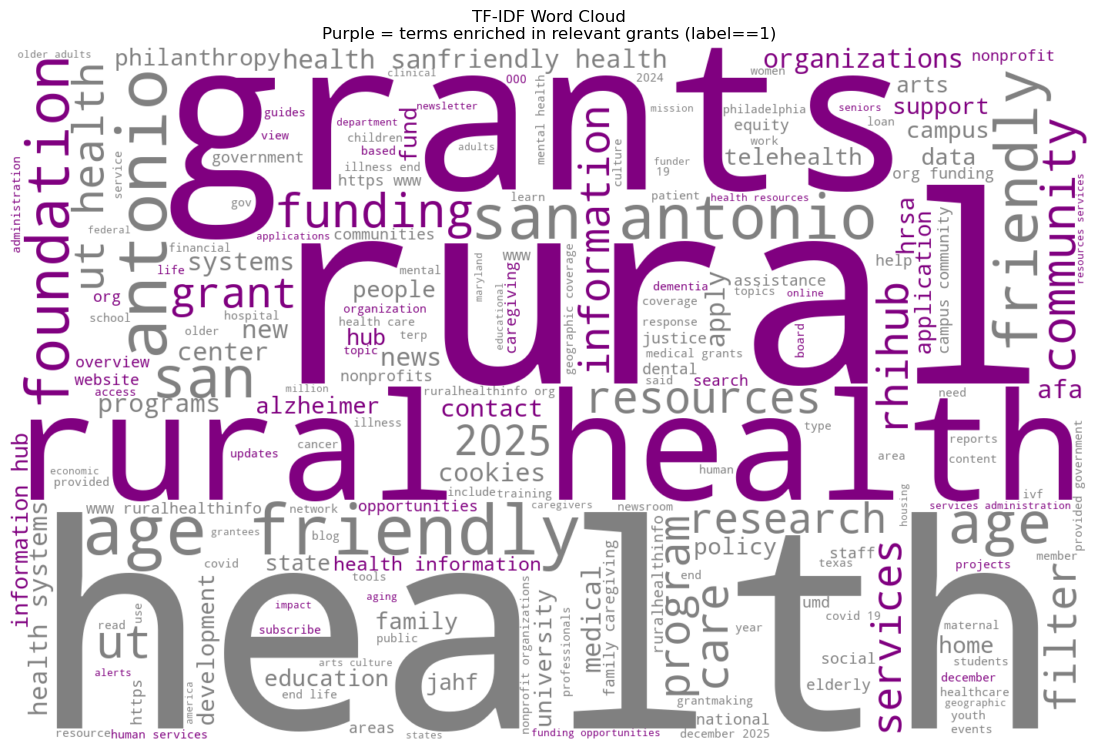

In [81]:
plot_relevance_wordcloud(
    df_corp,
    text_col="text",
    label_col="label",
    max_features=5000,
    rel_label=1,
    rel_boost_ratio=1.5,    # higher = stricter "relevance" to label==1
    top_k_terms=300         # optional: only plot top 300 terms
)


# Final Relevence Model SVM; LR; NAIVE BAYES comparison

In [13]:
import pandas as pd
import numpy as np
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# ---------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------
# basic cleaning
df = df[df["doc_id"].notna() & (df["doc_id"].astype(str).str.strip() != "")]
df = df[df["text_path"].notna()]
df = df[df["relevence_label"].notna()]

# binary label: 1 = relevant, 0 = not relevant
df["label"] = df["relevence_label"].astype(int)

print("total labeled rows:", len(df))
print("relevant (1):", (df["label"] == 1).sum())
print("not relevant (0):", (df["label"] == 0).sum())



total labeled rows: 1013
relevant (1): 28
not relevant (0): 985


In [15]:
# ---------------------------------------------------------
# TRAIN / TEST SPLIT (20 pos in train, ~725 total train)
# ---------------------------------------------------------
pos = df[df["label"] == 1]
neg = df[df["label"] == 0]

train_pos_target = 20
train_total_target = 725
train_neg_target = train_total_target - train_pos_target  # ~705

train_pos_target = min(train_pos_target, len(pos))
train_neg_target = min(train_neg_target, len(neg))

train_pos = pos.sample(n=train_pos_target, random_state=42)
train_neg = neg.sample(n=train_neg_target, random_state=42)

train_idx = train_pos.index.union(train_neg.index)
train_df = df.loc[train_idx].copy()
test_df = df.drop(train_idx).copy()

print("\ntrain size:", len(train_df))
print("  train relevant:", (train_df["label"] == 1).sum())
print("  train not relevant:", (train_df["label"] == 0).sum())

print("\ntest size:", len(test_df))
print("  test relevant:", (test_df["label"] == 1).sum())
print("  test not relevant:", (test_df["label"] == 0).sum())


train size: 725
  train relevant: 20
  train not relevant: 705

test size: 288
  test relevant: 8
  test not relevant: 280


In [17]:
# ---------------------------------------------------------
# LOAD RAW TEXT
# ---------------------------------------------------------
def load_text(path):
    try:
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            return f.read()
    except Exception as e:
        print("error reading", path, ":", e)
        return ""

train_df["raw_text"] = train_df["text_path"].apply(load_text)
test_df["raw_text"] = test_df["text_path"].apply(load_text)

x_train_text = train_df["raw_text"].tolist()
y_train = train_df["label"].values

x_test_text = test_df["raw_text"].tolist()
y_test = test_df["label"].values

In [19]:
# ---------------------------------------------------------
# TF-IDF VECTORIZER (fit on TRAIN only)
# ---------------------------------------------------------
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

x_train = vectorizer.fit_transform(x_train_text)
x_test = vectorizer.transform(x_test_text)


In [21]:
# ---------------------------------------------------------
# STRATIFIED K-FOLD ON TRAIN ONLY
# ---------------------------------------------------------
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def eval_model_kfold(model, x, y):
    p_scores = []
    r_scores = []
    f_scores = []

    for train_idx_fold, val_idx_fold in kfold.split(x, y):
        x_tr = x[train_idx_fold]
        x_val = x[val_idx_fold]
        y_tr = y[train_idx_fold]
        y_val = y[val_idx_fold]

        model.fit(x_tr, y_tr)
        preds = model.predict(x_val)

        p = precision_score(y_val, preds, pos_label=1, zero_division=0)
        r = recall_score(y_val, preds, pos_label=1, zero_division=0)
        f = f1_score(y_val, preds, pos_label=1, zero_division=0)

        p_scores.append(p)
        r_scores.append(r)
        f_scores.append(f)

    return np.mean(p_scores), np.mean(r_scores), np.mean(f_scores)

In [23]:
# ---------------------------------------------------------
# TUNING: LOGISTIC REGRESSION
# ---------------------------------------------------------
lr_results = []

for c in [0.01, 0.1, 1, 10]:
    lr = LogisticRegression(
        C=c,
        class_weight="balanced",
        max_iter=2000
    )
    p, r, f = eval_model_kfold(lr, x_train, y_train)
    lr_results.append([c, p, r, f])

lr_df = pd.DataFrame(lr_results, columns=["C", "precision", "recall", "f1"])
print("\nLOGISTIC REGRESSION TUNING (train, 5-fold)")
print(lr_df)

best_lr_row = lr_df.loc[lr_df["f1"].idxmax()]
best_lr_c = best_lr_row["C"]
print("\nBest LR C based on F1:", best_lr_c)




LOGISTIC REGRESSION TUNING (train, 5-fold)
       C  precision  recall        f1
0   0.01   0.067727    0.45  0.116191
1   0.10   0.094803    0.50  0.155682
2   1.00   0.154595    0.50  0.227931
3  10.00   0.366667    0.40  0.371429

Best LR C based on F1: 10.0


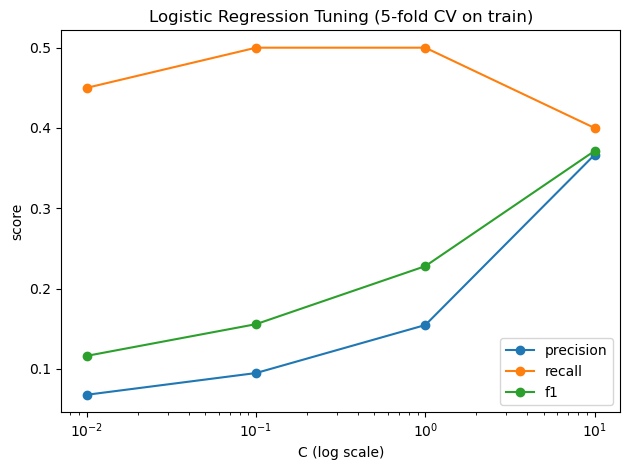

In [25]:
plt.figure()
plt.plot(lr_df["C"], lr_df["precision"], marker="o", label="precision")
plt.plot(lr_df["C"], lr_df["recall"], marker="o", label="recall")
plt.plot(lr_df["C"], lr_df["f1"], marker="o", label="f1")

plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("score")
plt.title("Logistic Regression Tuning (5-fold CV on train)")
plt.legend()
plt.tight_layout()
plt.show()


NAIVE BAYES TUNING (train, 5-fold)
   alpha  precision  recall        f1
0    0.1   0.078571    0.15  0.094444
1    0.5   0.000000    0.00  0.000000
2    1.0   0.000000    0.00  0.000000

Best NB alpha based on F1: 0.1


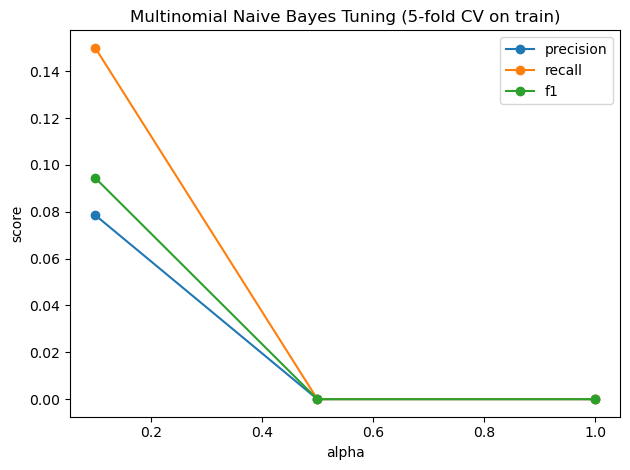

In [27]:
# ---------------------------------------------------------
# TUNING: MULTINOMIAL NAIVE BAYES
# ---------------------------------------------------------
nb_results = []

for alpha in [0.1, 0.5, 1.0]:
    nb = MultinomialNB(alpha=alpha)
    p, r, f = eval_model_kfold(nb, x_train, y_train)
    nb_results.append([alpha, p, r, f])

nb_df = pd.DataFrame(nb_results, columns=["alpha", "precision", "recall", "f1"])
print("\nNAIVE BAYES TUNING (train, 5-fold)")
print(nb_df)

best_nb_row = nb_df.loc[nb_df["f1"].idxmax()]
best_nb_alpha = best_nb_row["alpha"]
print("\nBest NB alpha based on F1:", best_nb_alpha)

plt.figure()
plt.plot(nb_df["alpha"], nb_df["precision"], marker="o", label="precision")
plt.plot(nb_df["alpha"], nb_df["recall"], marker="o", label="recall")
plt.plot(nb_df["alpha"], nb_df["f1"], marker="o", label="f1")

plt.xlabel("alpha")
plt.ylabel("score")
plt.title("Multinomial Naive Bayes Tuning (5-fold CV on train)")
plt.legend()
plt.tight_layout()
plt.show()

NB cannot overcome class imbalance — even with smoothing

NB does not support class_weight="balanced" and cannot compensate via:

priors

smoothing

alpha tuning

In extreme imbalance, NB collapses.

Naive Bayes relies on word frequency signals and assumes independence among terms. With only 20 positive examples and a highly imbalanced corpus, it dramatically underestimates the probability of the relevant class. TF-IDF exacerbates this problem by removing the raw count information NB depends on, causing the model to predict almost all documents as not relevant. As a result, precision, recall, and F1 collapse toward zero. Models like Logistic Regression and Linear SVM are much more suitable for sparse, semantic text classification with rare positive cases.

C:\Users\miked\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\miked\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\miked\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\miked\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\miked\anaconda3\Lib\site-packages\sklearn\svm\_clas


LINEAR SVM TUNING (train, 5-fold)
       C  precision  recall        f1
0   0.01   0.072982    0.55  0.127637
1   0.10   0.138192    0.55  0.217581
2   1.00   0.346667    0.35  0.340317
3  10.00   0.440000    0.30  0.349206

Best SVM C based on F1: 10.0


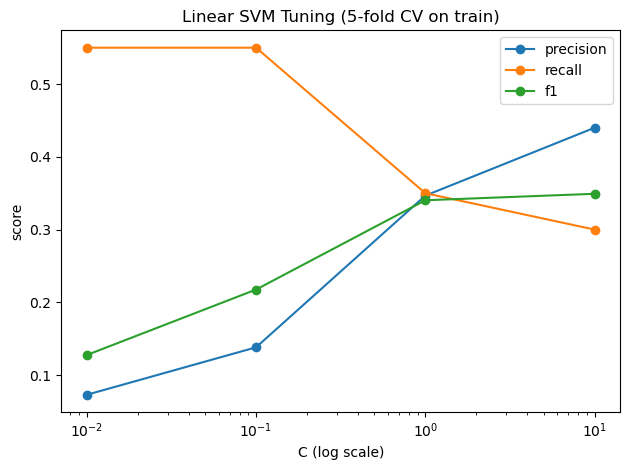

In [29]:
# ---------------------------------------------------------
# TUNING: LINEAR SVM
# ---------------------------------------------------------
svm_results = []

for c in [0.01, 0.1, 1, 10]:
    svm = LinearSVC(
        C=c,
        class_weight="balanced"
    )
    p, r, f = eval_model_kfold(svm, x_train, y_train)
    svm_results.append([c, p, r, f])

svm_df = pd.DataFrame(svm_results, columns=["C", "precision", "recall", "f1"])
print("\nLINEAR SVM TUNING (train, 5-fold)")
print(svm_df)

best_svm_row = svm_df.loc[svm_df["f1"].idxmax()]
best_svm_c = best_svm_row["C"]
print("\nBest SVM C based on F1:", best_svm_c)

plt.figure()
plt.plot(svm_df["C"], svm_df["precision"], marker="o", label="precision")
plt.plot(svm_df["C"], svm_df["recall"], marker="o", label="recall")
plt.plot(svm_df["C"], svm_df["f1"], marker="o", label="f1")

plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("score")
plt.title("Linear SVM Tuning (5-fold CV on train)")
plt.legend()
plt.tight_layout()
plt.show()


Why We Used class_weight="balanced" in Logistic Regression, SVM, and Naive Bayes

Although our training split intentionally selects 20 relevant and ~705 not-relevant documents, the underlying data remain extremely imbalanced. Across the full corpus we identified only 28 relevant grants out of 1,013 total documents, meaning the positive class represents less than 3% of all cases.

Without addressing this imbalance, the models would learn to simply predict “not relevant” for everything, achieving high accuracy by ignoring the minority class. This would produce very poor recall and near-zero F1 scores—essentially defeating the purpose of building a relevance classifier.

To correct for this, we used:

class_weight="balanced"


in Logistic Regression and Linear SVM.

This does not balance the dataset. Instead, it automatically assigns a higher penalty to misclassifying the positive class, ensuring the model:

does not collapse into predicting only the majority class,

treats relevant grants as equally important during training despite their rarity,

improves recall for the minority class,

and ultimately provides a more useful decision boundary for identifying mission-aligned grants.

In a highly skewed problem like ours, class weighting is standard practice and essential for producing a model that actually finds relevant opportunities rather than optimizing for accuracy alone.

In [31]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# ---------------------------------------------------------
# FINAL TRAINING ON FULL TRAIN SET WITH BEST PARAMS
# ---------------------------------------------------------
best_lr = LogisticRegression(
    C=best_lr_c,
    class_weight="balanced",
    max_iter=2000
)
best_lr.fit(x_train, y_train)

best_nb = MultinomialNB(alpha=best_nb_alpha)
best_nb.fit(x_train, y_train)

best_svm = LinearSVC(
    C=best_svm_c,
    class_weight="balanced"
)
best_svm.fit(x_train, y_train)

C:\Users\miked\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\miked\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(C=10.0, class_weight='balanced')

In [33]:
# ---------------------------------------------------------
# STEP C: THRESHOLD TUNING FOR LOGISTIC REGRESSION (TRAIN ONLY)
# ---------------------------------------------------------
train_probs_lr = best_lr.predict_proba(x_train)[:, 1]

thresholds = np.linspace(0.05, 0.95, 19)
best_t = 0.5
best_f1 = 0.0

for t in thresholds:
    preds_t = (train_probs_lr >= t).astype(int)
    f = f1_score(y_train, preds_t, pos_label=1, zero_division=0)
    if f > best_f1:
        best_f1 = f
        best_t = t

print("best LR threshold on training:", best_t, "with F1:", best_f1)

best LR threshold on training: 0.85 with F1: 0.926829268292683


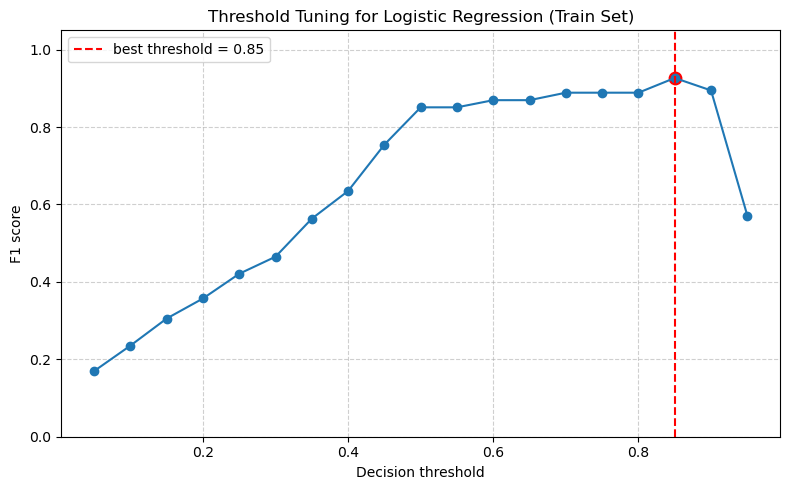

In [51]:
# ---------------------------------------------------------
# VISUALIZE THRESHOLD TUNING (F1 vs threshold)
# ---------------------------------------------------------
f1_scores = []

for t in thresholds:
    preds_t = (train_probs_lr >= t).astype(int)
    f = f1_score(y_train, preds_t, pos_label=1, zero_division=0)
    f1_scores.append(f)

plt.figure(figsize=(8,5))
plt.plot(thresholds, f1_scores, marker="o")
plt.axvline(best_t, color="red", linestyle="--", label=f"best threshold = {round(best_t,3)}")
plt.scatter([best_t], [best_f1], color="red", s=80)

plt.title("Threshold Tuning for Logistic Regression (Train Set)")
plt.xlabel("Decision threshold")
plt.ylabel("F1 score")
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [35]:
# ---------------------------------------------------------
# STEP D: FINAL TEST PREDICTIONS (USING TUNED LR THRESHOLD)
# ---------------------------------------------------------
# logistic regression with tuned threshold
test_probs_lr = best_lr.predict_proba(x_test)[:, 1]
y_pred_lr = (test_probs_lr >= best_t).astype(int)

# naive bayes and svm with default decision rule
y_pred_nb = best_nb.predict(x_test)
y_pred_svm = best_svm.predict(x_test)

In [37]:
# ---------------------------------------------------------
# FINAL TEST EVALUATION
# ---------------------------------------------------------
def report_model(name, y_true, y_pred):
    p = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    r = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    print("\n" + name)
    print("  precision:", round(p, 3))
    print("  recall   :", round(r, 3))
    print("  f1       :", round(f, 3))

print("\n================ FINAL TEST PERFORMANCE ================")
report_model("Logistic Regression (best C, tuned threshold)", y_test, y_pred_lr)
report_model("Naive Bayes (best alpha)", y_test, y_pred_nb)
report_model("Linear SVM (best C)", y_test, y_pred_svm)

# collect test metrics for each best model
model_names = ["LogReg", "NaiveBayes", "LinearSVM"]
precisions = []
recalls = []
f1s = []

# Logistic Regression
precisions.append(precision_score(y_test, y_pred_lr, pos_label=1, zero_division=0))
recalls.append(recall_score(y_test, y_pred_lr, pos_label=1, zero_division=0))
f1s.append(f1_score(y_test, y_pred_lr, pos_label=1, zero_division=0))

# Naive Bayes
precisions.append(precision_score(y_test, y_pred_nb, pos_label=1, zero_division=0))
recalls.append(recall_score(y_test, y_pred_nb, pos_label=1, zero_division=0))
f1s.append(f1_score(y_test, y_pred_nb, pos_label=1, zero_division=0))

# Linear SVM
precisions.append(precision_score(y_test, y_pred_svm, pos_label=1, zero_division=0))
recalls.append(recall_score(y_test, y_pred_svm, pos_label=1, zero_division=0))
f1s.append(f1_score(y_test, y_pred_svm, pos_label=1, zero_division=0))


================ FINAL TEST PERFORMANCE ================

Logistic Regression (best C, tuned threshold)
  precision: 0.75
  recall   : 0.375
  f1       : 0.5

Naive Bayes (best alpha)
  precision: 0.0
  recall   : 0.0
  f1       : 0.0

Linear SVM (best C)
  precision: 0.833
  recall   : 0.625
  f1       : 0.714


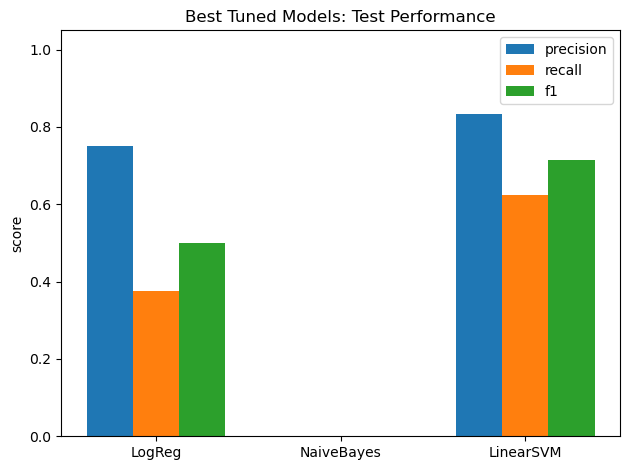

In [39]:
# make bar chart
x = np.arange(len(model_names))
width = 0.25

plt.figure()
plt.bar(x - width, precisions, width, label="precision")
plt.bar(x,         recalls,   width, label="recall")
plt.bar(x + width, f1s,       width, label="f1")

plt.xticks(x, model_names)
plt.ylim(0, 1.05)
plt.ylabel("score")
plt.title("Best Tuned Models: Test Performance")
plt.legend()
plt.tight_layout()
plt.show()


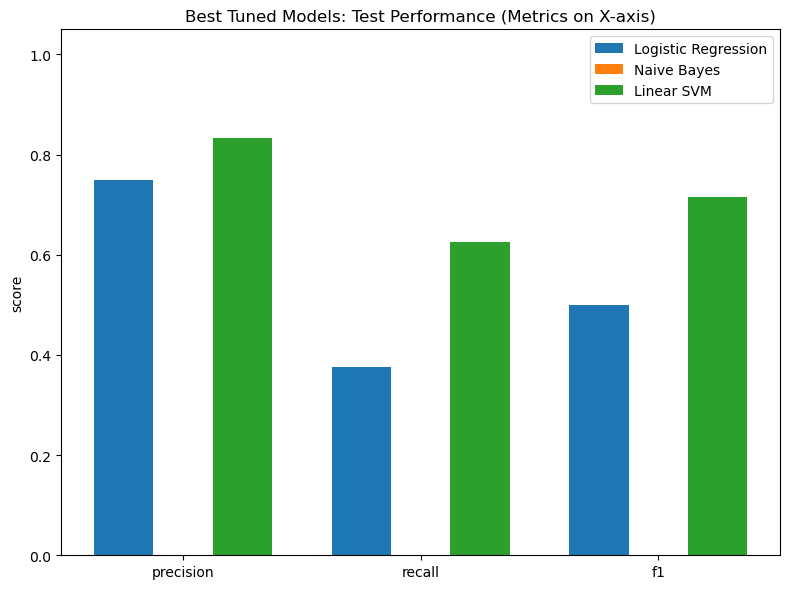

In [43]:
metrics = ["precision", "recall", "f1"]

# Stack metrics so rows = metrics, columns = models
vals = np.array([
    precisions,   # [LR, NB, SVM] for precision
    recalls,      # [LR, NB, SVM] for recall
    f1s           # [LR, NB, SVM] for f1
])

x = np.arange(len(metrics))  # 3 metrics
width = 0.25

plt.figure(figsize=(8,6))

plt.bar(x - width, vals[:,0], width, label="Logistic Regression")
plt.bar(x,         vals[:,1], width, label="Naive Bayes")
plt.bar(x + width, vals[:,2], width, label="Linear SVM")

plt.xticks(x, metrics)
plt.ylim(0, 1.05)
plt.ylabel("score")
plt.title("Best Tuned Models: Test Performance (Metrics on X-axis)")
plt.legend()
plt.tight_layout()
plt.show()


In [49]:
import os
import joblib

SAVE_DIR = r"C:\Users\miked\Desktop2\IConnectFoundation\grantMinded"

# ensure main directory exists (it should)
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(vectorizer,
    os.path.join(SAVE_DIR, "relevance_vectorizer.joblib"))

joblib.dump(best_lr,
    os.path.join(SAVE_DIR, "relevance_logreg_best.joblib"))

joblib.dump(best_nb,
    os.path.join(SAVE_DIR, "relevance_nb_best.joblib"))

joblib.dump(best_svm,
    os.path.join(SAVE_DIR, "relevance_svm_best.joblib"))

print("\nmodels and vectorizer saved in grantMinded folder.")



models and vectorizer saved in grantMinded folder.
